# Estimation of CX with MutliTreatment DLM

This notebook presents the **estimation of cx** case with MultitreatmentIRM model

# The problem

When analyzing customer experience, we encounter the problem that there may be multiple impacts that overlap. We can no longer encode treatments binary, so we create groups of unique clients that do not overlap. Let's look at an example from a large fintech company.

We think the effect depends on how users were exposed to the product.

We segmented users and now want to estimate the effect for each group.

- **Target**
  - `y` — binary target variable representing product utilization.

- **Treatments (problems)**
  - `neg_contact_flg` — negative contact to support
  - `error_flg` — repeat application / error flag of application.
  - `neg_contact_flg_error_flg` — joint treatment where both problem flags are present.
  - `control` — baseline group with no problem flag.

- **Strong confounders (past applications/utilization history)**
  - `prev_apps` — past applications.
  - `prev_util` — past utilization events.

- **Features (covariates)**
  - `age` — age.
  - `risk_latent` — latent risk factor.
  - `income` — income.
  - `sessions_30d` — sessions in the last 30 days.
  - `clicks_7d` — clicks in the last 7 days.
  - `n_products` — number of products.
  - `has_debt` — debt flag.
  - `csat_prev` — previous CSAT score.
  - `prev_contact` — past contact history.
  - `prev_repeat` — past repeat-application history.
  - `channel` — application channel, represented in the generated dataset as one-hot columns:
    `channel_callcenter`, `channel_partner`, `channel_web` with `app` as the reference level.
  - `region` — region, represented in the generated dataset as one-hot columns:
    `region_B`, `region_C`, `region_D` with `A` as the reference level.

- **Noise features**
  - `product_emb_1`, `product_emb_2` — no-signal features.

# Data

In [1]:
# !pip install causalis

In [2]:
from causalis.scenarios.multi_unconfoundedness.dgp import generate_multi_dml_cx_26

df = generate_multi_dml_cx_26(return_causal_data=False, include_oracle=True)

In [3]:
df.head()

,y,control,neg_contact_flg,error_flg,neg_contact_flg_error_flg,age,risk_latent,income,sessions_30d,clicks_7d,...,m_neg_contact_flg_error_flg,m_obs_neg_contact_flg_error_flg,tau_link_neg_contact_flg_error_flg,g_control,g_neg_contact_flg,g_error_flg,g_neg_contact_flg_error_flg,cate_neg_contact_flg,cate_error_flg,cate_neg_contact_flg_error_flg
0,1.0,0.0,0.0,1.0,0.0,40.0,0.612945,127181.894679,3.0,18.0,...,0.470037,0.470037,-0.65,0.800935,0.800935,0.677465,0.677465,0.0,-0.123470,-0.123470
1,0.0,0.0,0.0,0.0,1.0,26.0,-1.690640,43362.759375,8.0,5.0,...,0.072174,0.072174,-0.65,0.230696,0.230696,0.135359,0.135359,0.0,-0.095337,-0.095337
2,0.0,0.0,0.0,0.0,1.0,45.0,-0.288110,117069.035626,11.0,18.0,...,0.089019,0.089019,-0.65,0.362256,0.362256,0.228714,0.228714,0.0,-0.133542,-0.133542
3,1.0,0.0,0.0,0.0,1.0,47.0,0.441636,123821.130662,14.0,16.0,...,0.341129,0.341129,-0.65,0.716481,0.716481,0.568828,0.568828,0.0,-0.147653,-0.147653
4,1.0,0.0,0.0,0.0,1.0,18.0,-0.722611,36012.152571,8.0,18.0,...,0.067662,0.067662,-0.65,0.212228,0.212228,0.123300,0.123300,0.0,-0.088928,-0.088928


In [4]:
print(f"Ground truth ATE for neg_contact_flg vs control is {df['cate_neg_contact_flg'].mean()}")
print(f"Ground truth ATE for error_flg vs control is {df['cate_error_flg'].mean()}")
print(f"Ground truth ATE for neg_contact_flg_error_flg vs control is {df['cate_neg_contact_flg_error_flg'].mean()}")

Ground truth ATE for neg_contact_flg vs control is 0.0
Ground truth ATE for error_flg vs control is -0.12500559719513468
Ground truth ATE for neg_contact_flg_error_flg vs control is -0.12500559719513468


In [5]:
from causalis.data_contracts.multicausaldata import MultiCausalData

multi_causaldata = MultiCausalData(
    df=df,
    treatment_names=['control', 'neg_contact_flg', 'error_flg', 'neg_contact_flg_error_flg'],
    control_treatment='control',
    outcome='y',
    confounders=[
        'age', 'risk_latent', 'income', 'sessions_30d', 'clicks_7d', 'n_products',
        'has_debt', 'csat_prev', 'prev_contact', 'prev_repeat', 'prev_apps',
        'prev_util', 'product_emb_1', 'product_emb_2', 'channel_callcenter',
        'channel_partner', 'channel_web', 'region_B', 'region_C', 'region_D'
    ]
)
multi_causaldata

MultiCausalData(df=(100000, 25), treatment_names=['control', 'neg_contact_flg', 'error_flg', 'neg_contact_flg_error_flg'], control_treatment='control')outcome='y', confounders=['age', 'risk_latent', 'income', 'sessions_30d', 'clicks_7d', 'n_products', 'has_debt', 'csat_prev', 'prev_contact', 'prev_repeat', 'prev_apps', 'prev_util', 'product_emb_1', 'product_emb_2', 'channel_callcenter', 'channel_partner', 'channel_web', 'region_B', 'region_C', 'region_D'], user_id=None, 

# EDA

In [6]:
from causalis.shared import outcome_stats
outcome_stats(multi_causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,error_flg,17607,0.450162,0.497524,0.0,0.0,0.0,0.0,1.0,1.0,1.0
1,neg_contact_flg_error_flg,15259,0.519955,0.499618,0.0,0.0,0.0,1.0,1.0,1.0,1.0
2,control,42244,0.501894,0.500002,0.0,0.0,0.0,1.0,1.0,1.0,1.0
3,neg_contact_flg,24890,0.579068,0.493719,0.0,0.0,0.0,1.0,1.0,1.0,1.0


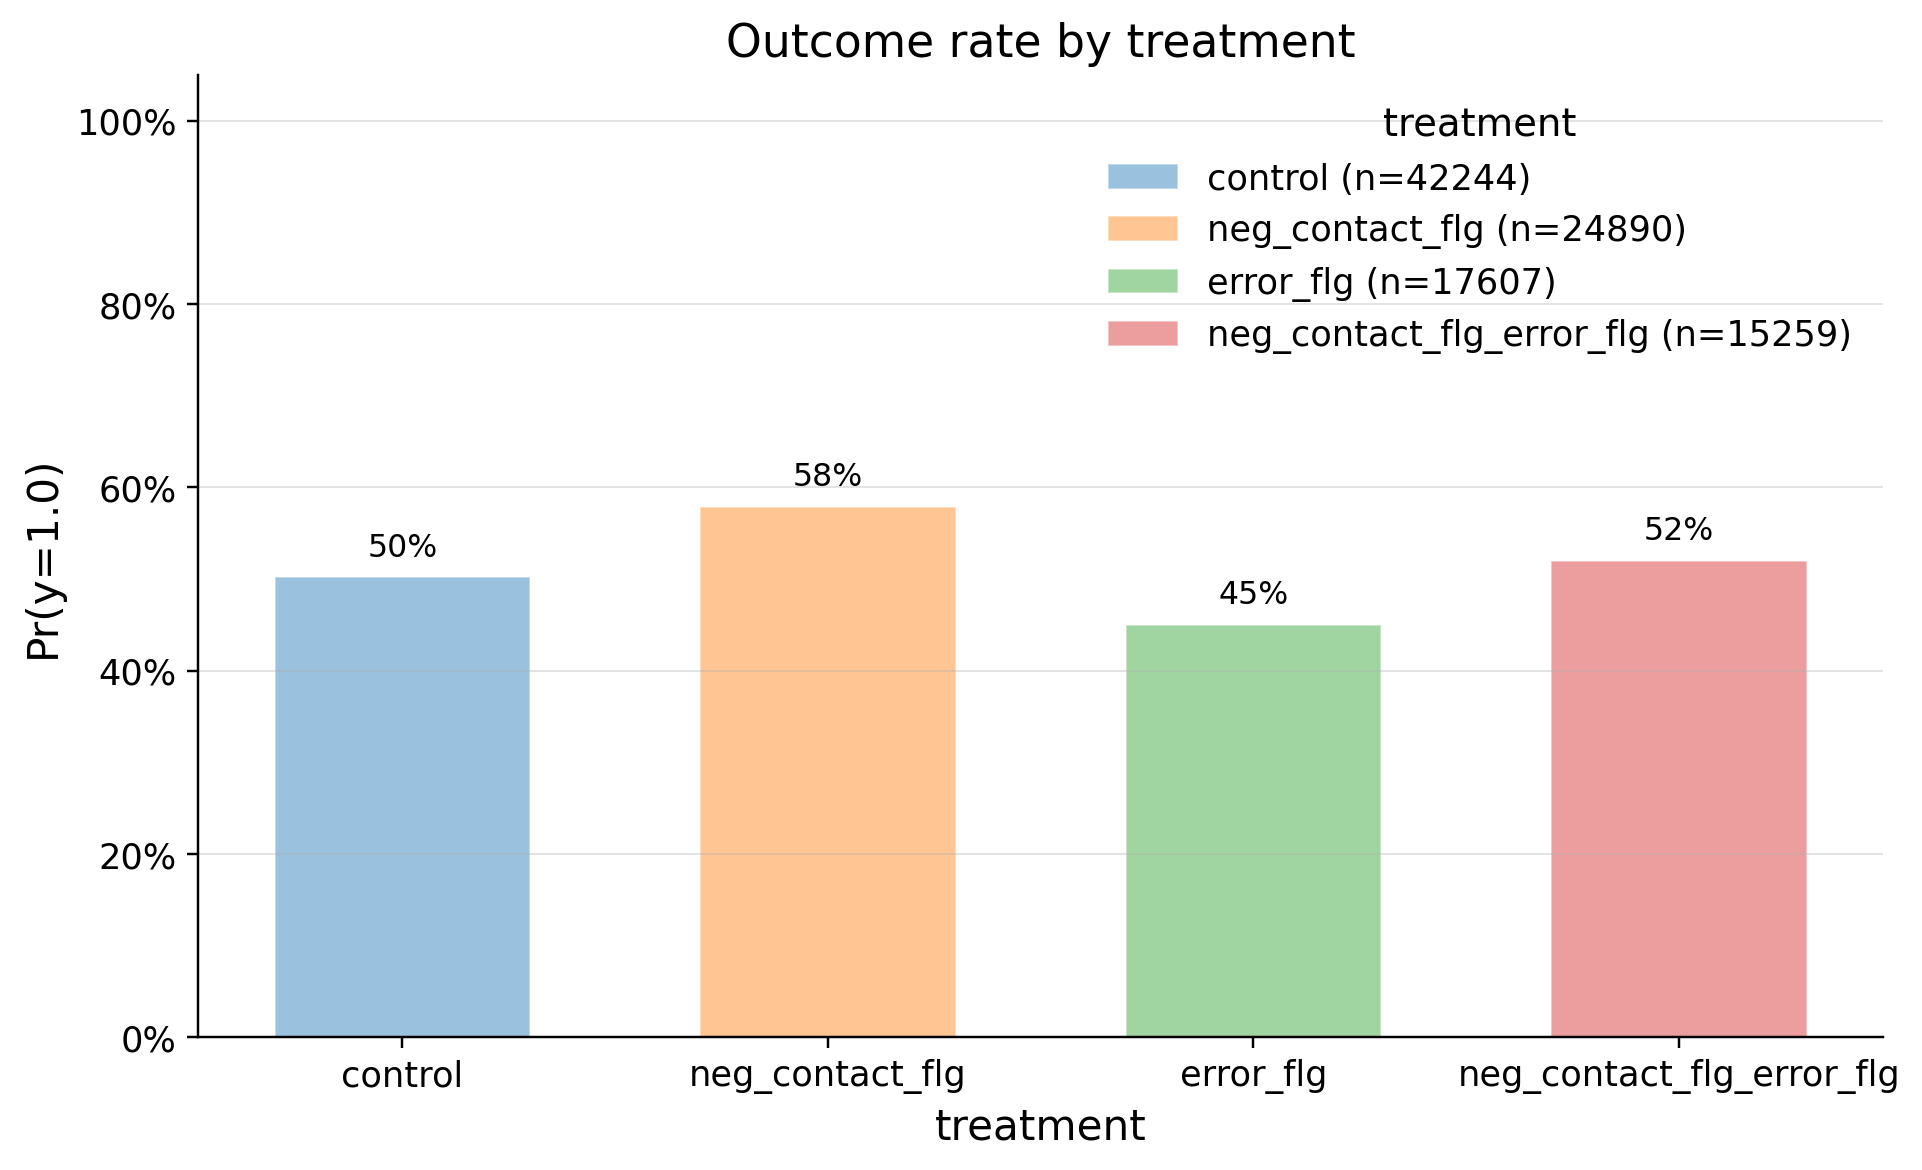

In [7]:
from causalis.shared.outcome_plots import outcome_plot_dist
outcome_plot_dist(multi_causaldata)

In [8]:
from causalis.shared import confounders_balance

confounders_balance(multi_causaldata, 'control', 'error_flg')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,channel_web,0.793225,0.017947,0.775278,-2.572501,0.00000
1,channel_partner,0.000166,0.427500,0.427335,1.221147,0.00000
2,channel_callcenter,0.000000,0.088147,0.088147,0.439687,0.00000
3,prev_repeat,0.125935,0.301585,0.175650,0.438630,0.00000
4,age,35.862111,39.984608,4.122498,0.392401,0.00000
5,prev_apps,0.251373,0.348441,0.097068,0.213032,0.00000
6,risk_latent,-0.187654,-0.008340,0.179315,0.182731,0.00000
7,prev_util,0.323312,0.389220,0.065908,0.137949,0.00000
8,has_debt,0.272559,0.308684,0.036125,0.079622,0.00000
9,clicks_7d,13.555440,13.775885,0.220445,0.058115,0.00000


In [9]:
confounders_balance(multi_causaldata, 'control', 'neg_contact_flg')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,channel_web,0.793225,0.254560,0.538665,-1.280740,0.00000
1,prev_contact,0.109743,0.487465,0.377721,0.906097,0.00000
2,channel_partner,0.000166,0.082523,0.082357,0.422814,0.00000
3,risk_latent,-0.187654,0.124121,0.311775,0.317290,0.00000
4,prev_apps,0.251373,0.333548,0.082175,0.181385,0.00000
5,sessions_30d,9.108370,9.663761,0.555390,0.177521,0.00000
6,prev_util,0.323312,0.394777,0.071465,0.149384,0.00000
7,csat_prev,3.992626,3.913419,0.079206,-0.135992,0.00000
8,has_debt,0.272559,0.313419,0.040860,0.089864,0.00000
9,income,83694.312863,86202.400216,2508.087352,0.083142,0.00000


In [10]:
confounders_balance(multi_causaldata, 'control', 'neg_contact_flg_error_flg')

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,channel_web,0.793225,0.000983,0.792242,-2.758190,0.00000
1,channel_callcenter,0.000000,0.553837,0.553837,1.575597,0.00000
2,channel_partner,0.000166,0.347139,0.346974,1.030330,0.00000
3,prev_contact,0.109743,0.422701,0.312958,0.757096,0.00000
4,risk_latent,-0.187654,0.321338,0.508992,0.519183,0.00000
5,prev_repeat,0.125935,0.293138,0.167203,0.419783,0.00000
6,prev_apps,0.251373,0.444525,0.193152,0.414100,0.00000
7,age,35.862111,39.988793,4.126683,0.394090,0.00000
8,prev_util,0.323312,0.472049,0.148737,0.307469,0.00000
9,sessions_30d,9.108370,9.892260,0.783890,0.247583,0.00000


# Training the Model and Reviewing the Results

In [11]:
from causalis.scenarios.multi_unconfoundedness import MultiTreatmentIRM

model = MultiTreatmentIRM().fit(multi_causaldata)

In [12]:
dml_result = model.estimate(score='ATE')
dml_result.summary()

,neg_contact_flg vs control,error_flg vs control,neg_contact_flg_error_flg vs control
field,,,
estimand,ATE,ATE,ATE
model,MultiTreatmentIRM,MultiTreatmentIRM,MultiTreatmentIRM
value,"-0.0036 (ci_abs: -0.0067, -0.0005)","-0.1220 (ci_abs: -0.1258, -0.1182)","-0.1141 (ci_abs: -0.1174, -0.1108)"
value_relative,"-0.6415 (ci_rel: -1.1946, -0.0883)","-21.8757 (ci_rel: -22.5073, -21.2442)","-20.4580 (ci_rel: -20.9967, -19.9193)"
alpha,0.0500,0.0500,0.0500
p_value,0.0233,0.0000,0.0000
is_significant,False,True,True
n_treated,24890,17607,15259
n_control,42244,42244,42244


"Error" or "Negative Contact + Error" decreases probability to utilization in product by 11 p.p

# Refutation

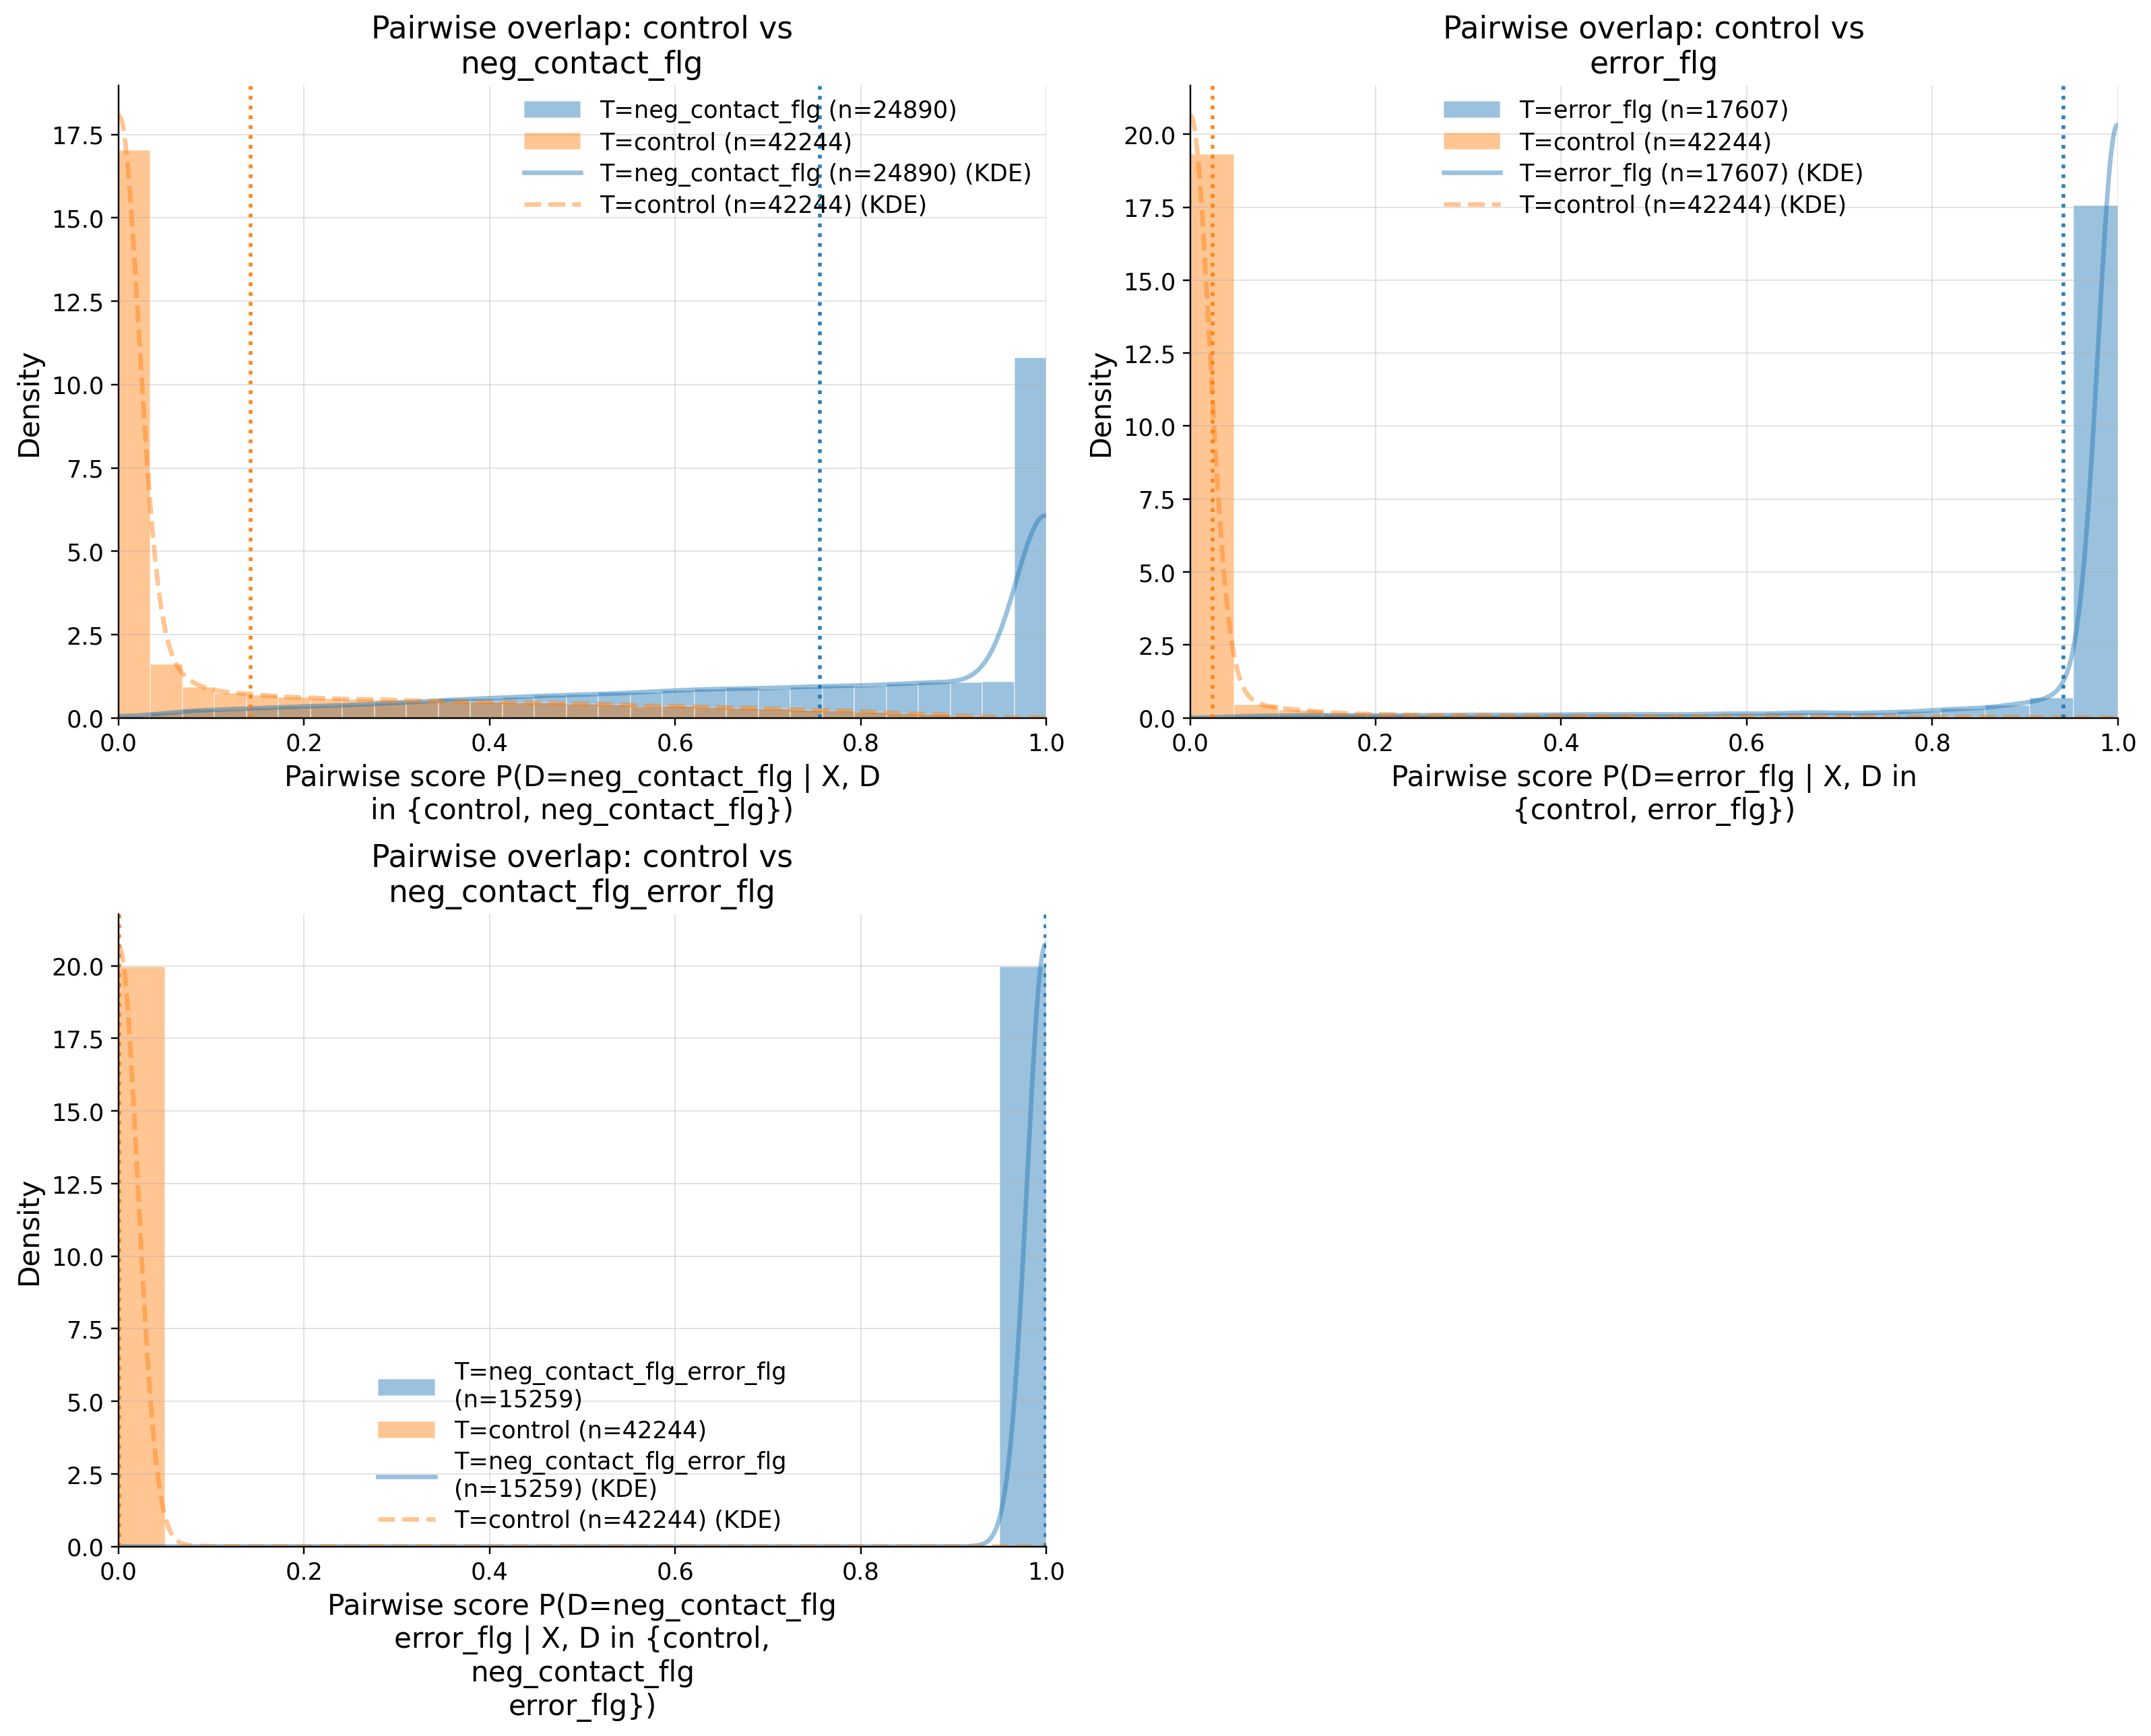

In [13]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import overlap_plot

overlap_plot(multi_causaldata, dml_result)

In [14]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import run_overlap_diagnostics

report = run_overlap_diagnostics(multi_causaldata, dml_result)
report["summary"]
report["overlap"]["by_comparison"]


,comparison,n_pair,n_treated,n_baseline,edge_0.01_below,edge_0.01_above,ks,auc,ess_ratio_treated,ess_ratio_baseline,...,clip_m_baseline,clip_m_total,flag_edge_001,flag_ks,flag_auc,flag_ess_treated,flag_ess_baseline,flag_clip_m,overall_flag,pass
0,control vs neg_contact_flg,67134,24890,42244,0.296273,0.125659,0.718263,0.945453,0.348940,0.165737,...,0.131737,0.429499,RED,RED,RED,GREEN,YELLOW,RED,RED,False
1,control vs error_flg,59851,17607,42244,0.606773,0.221584,0.950640,0.998057,0.305756,0.165737,...,0.227715,0.849643,RED,RED,RED,GREEN,YELLOW,RED,RED,False
2,control vs neg_contact_flg_error_flg,57503,15259,42244,0.726136,0.263899,0.999834,1.000000,0.283149,0.165737,...,0.265151,0.999409,RED,RED,RED,YELLOW,YELLOW,RED,RED,False


In [15]:
from causalis.scenarios.multi_unconfoundedness.refutation.overlap import run_overlap_diagnostics
rep_overlap = run_overlap_diagnostics(multi_causaldata, dml_result)
rep_overlap["summary"]

,comparison,metric,value,flag
0,control vs neg_contact_flg,edge_0.01_below,0.296273,RED
1,control vs neg_contact_flg,edge_0.01_above,0.125659,RED
2,control vs neg_contact_flg,KS,0.718263,RED
3,control vs neg_contact_flg,AUC,0.945453,RED
4,control vs neg_contact_flg,ESS_treated_ratio,0.34894,GREEN
5,control vs neg_contact_flg,ESS_baseline_ratio,0.165737,YELLOW
6,control vs neg_contact_flg,clip_m_total,0.429499,RED
7,control vs neg_contact_flg,overlap_pass,False,RED
8,control vs error_flg,edge_0.01_below,0.606773,RED
9,control vs error_flg,edge_0.01_above,0.221584,RED


Because “bad overlap” and “accurate point estimate” are different things here.

- Your overlap is genuinely bad, not a plotting bug. The notebook diagnostics are extreme: `KS = 0.716 / 0.951 / 0.9997`, `AUC = 0.945 / 0.998 / 1.0`, and `clip_m_total = 0.43 / 0.85 / 0.999` for the three pairwise comparisons. That means the arms are almost perfectly separable in propensity space.
- This is expected from the CX DGP. Treatment assignment is intentionally very predictable from observed history: `prev_contact` enters the contact logit with coefficient `2.20`, `prev_repeat` enters the repeat logit with coefficient `1.30`, and the joint arm literally uses `contact_logit + repeat_logit` as its score. So near-deterministic assignment is baked into the benchmark.
- The outcome side is much easier than the treatment side. In this DGP the treatment effects are constant on the link scale: `theta=[0.0, 0.0, -0.65, -0.65]` and `tau=[None, None, None, None]` . So `neg_contact_flg` truly has zero effect, and `error_flg` and `neg_contact_flg_error_flg` have the same effect by construction.
- There is also no hidden confounding in the generator defaults: `u_strength_y=0.0` and `u_strength_d=0.0` . So all the variables driving treatment are observed in `X`, which makes the synthetic problem much friendlier than real data.
- `MultiTreatmentIRM` is not pure IPW. Its score is orthogonal / AIPW-style, combining outcome regression `g_hat` with residual weighting by `1 / m_hat`. If `g_hat` is learned well, the ATE can still be accurate even when overlap is weak.
- You also have a huge sample. Even with poor overlap, the ESS ratios still leave thousands of effective observations: roughly `9.6k`, `5.3k`, and `3.8k` treated ESS, with about `11.3k` baseline ESS in each comparison. That is plenty for a simple constant-effect synthetic DGP.

One subtlety: the overlap plot and overlap diagnostics prefer `m_hat_raw` when available, while estimation uses trimmed `m_hat` with threshold `0.01`. So the diagnostic picture is intentionally harsher than the exact weights used in the score.

The takeaway is: this overlap is bad, but the estimate is still close to oracle because the benchmark is very favorable to outcome-model-based recovery. In real data, overlap this bad would make me treat the result as fragile and model-dependent, not reassuring. Your later sensitivity section is consistent with that: the bias-aware intervals get much wider even though the sampling CI is tight.

If you want, I can next help you answer one of these precisely:
1. whether the estimate is mostly coming from `g_hat` rather than IPW,
2. how much trimming is rescuing the estimate,
3. how to soften this DGP so overlap becomes realistic.

# Unconfoundedness

In [16]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness import run_unconfoundedness_diagnostics
rep_uc = run_unconfoundedness_diagnostics(multi_causaldata, dml_result)
rep_uc["summary"]  # comparison, metric, value, flag

,comparison,metric,value,flag
0,control vs neg_contact_flg,balance_max_smd,0.757665,RED
1,control vs neg_contact_flg,balance_frac_violations,0.25,RED
2,control vs neg_contact_flg,balance_pass,False,RED
3,control vs error_flg,balance_max_smd,1.653832,RED
4,control vs error_flg,balance_frac_violations,0.45,RED
5,control vs error_flg,balance_pass,False,RED
6,control vs neg_contact_flg_error_flg,balance_max_smd,1.957133,RED
7,control vs neg_contact_flg_error_flg,balance_frac_violations,0.65,RED
8,control vs neg_contact_flg_error_flg,balance_pass,False,RED
9,overall,balance_max_smd,1.957133,RED


In [17]:
rep_uc["balance"]["worst_features"]
rep_uc["balance"]["smd"].sort_values("control vs neg_contact_flg_error_flg", ascending=False).head(10)
rep_uc["balance"]["smd_unweighted"].sort_values("control vs neg_contact_flg_error_flg", ascending=False).head(10)


,control vs neg_contact_flg,control vs error_flg,control vs neg_contact_flg_error_flg
channel_web,1.280761,2.572535,2.758223
channel_callcenter,0.051529,0.439699,1.575648
channel_partner,0.422822,1.221182,1.030364
prev_contact,0.906113,0.057932,0.757117
risk_latent,0.317295,0.182735,0.519195
prev_repeat,0.029874,0.438640,0.419794
prev_apps,0.181388,0.213037,0.414109
age,0.029333,0.392409,0.394099
prev_util,0.149387,0.137952,0.307476
sessions_30d,0.177523,0.037726,0.247589


**`rep_uc` Meaning**
`run_unconfoundedness_diagnostics()` is checking weighted covariate balance after reweighting by the estimated multiclass propensities `d_k / m_hat_k`, then computing standardized mean differences (SMDs) between each treatment arm and control in  It uses the trimmed `m_hat` from the estimate, not `m_hat_raw`, so this is already judging the “safer” propensities actually used by the score in

Your numbers are a hard fail:
- `control vs neg_contact_flg`: `balance_max_smd = 0.75095`, `balance_frac_violations = 0.30`
- `control vs error_flg`: `balance_max_smd = 1.655942`, `balance_frac_violations = 0.45`
- `control vs neg_contact_flg_error_flg`: `balance_max_smd = 1.924802`, `balance_frac_violations = 0.65`
- Overall: `46.7%` of feature-comparison cells are still above the default SMD threshold `0.10`, and anything above `0.20` is already `RED` by the implementation in

**Why This Happens**
This does not mean the DGP violates unconfoundedness. In this synthetic CX setup, unconfoundedness is true by construction because treatment and outcome depend only on observed `X`, with no hidden `U` effect by default in the shared generator at  What fails is the practical balancing step induced by estimated propensities.

The reason is the treatment assignment is intentionally very sharp:
- `neg_contact_flg` is driven strongly by `prev_contact` with coefficient `2.20` in
- `error_flg` is driven by `prev_repeat` and related history in
- the joint arm uses the sum of both logits in

So the arms live in different parts of covariate space. Poor overlap means IPW cannot create balanced pseudo-populations because there just are not enough comparable controls and treated units to reweight into each other. That’s exactly why overlap and balance both fail.

**Why ATE Is Still Close**
The estimate can still be near oracle because `MultiTreatmentIRM` is doubly robust / outcome-augmented, not pure IPW. Its score combines outcome regression `g_hat` with weighted residual terms in . In this benchmark the treatment effect structure is very simple on the link scale, with `theta=[0.0, 0.0, -0.65, -0.65]` and no extra `tau(X)` in So `g_hat` can recover a lot even when weighting is weak.

That’s also why the pattern of errors makes sense:
- `neg_contact_flg` has the least-bad overlap/balance and smallest absolute miss from oracle
- `neg_contact_flg_error_flg` has the worst overlap/balance and the biggest miss

So the clean interpretation is:
- overlap diagnostics: bad
- balance diagnostics: bad even after trimming
- oracle vs estimate: still close because this synthetic problem is easy for the outcome model, not because the design is well supported

# Sensetivity analysis

In [18]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness.sensitivity import (
    sensitivity_analysis, get_sensitivity_summary
)

In [19]:
from causalis.scenarios.multi_unconfoundedness.refutation.unconfoundedness import sensitivity_benchmark


bench = sensitivity_benchmark(dml_result, benchmarking_set=["prev_contact", "prev_util"])
bench

,cf_y,r2_y,r2_d,rho,theta_long,theta_short,delta
neg_contact_flg vs control,0.00002,0.00002,0.000212,0.972781,-0.003577,0.019615,-0.023192
error_flg vs control,0.00002,0.00002,0.000109,0.888425,-0.121998,-0.088648,-0.033350
neg_contact_flg_error_flg vs control,0.00002,0.00002,0.000636,0.889238,-0.114092,-0.048212,-0.065880


In [20]:
res = sensitivity_analysis(
    dml_result,  # MultiCausalEstimate
    multi_causaldata,  # MultiCausalData (optional but recommended for validation)
    cf_y=0.05,  # confounding strength in outcome residual
    r2_d=0.05,  # confounding strength in treatment residual
    rho=1.0,
    H0=0.0,
    alpha=0.05,
)

res

================== Bias-aware Interval ==================

------------------ Scenario          ------------------
Significance Level: alpha=0.05
Null Hypothesis: H0=0.0
Sensitivity parameters: cf_y=0.05; r2_d=[0.05 0.05 0.05], rho=[1. 1. 1.], use_signed_rr=False

                                              statistics                       value
0             neg_contact_flg vs control | bias_aware_ci           [-0.1581, 0.1509]
1                     neg_contact_flg vs control | theta  [-0.1547, -0.0036, 0.1476]
2               neg_contact_flg vs control | sampling_ci          [-0.0067, -0.0005]
3                        neg_contact_flg vs control | rv                    0.000000
4                       neg_contact_flg vs control | rva                    0.000000
5                        neg_contact_flg vs control | se                    0.001600
6                  neg_contact_flg vs control | max_bias                    0.151100
7             neg_contact_flg vs control | max_bias_bas

# Summary
A regular contact/support request is not a problem, while submitting the application multiple times leads to a decrease in product utilization.